In [2]:
import gb

print("Coucou")

Coucou


### Détection et Nettoyage des Outliers

#### Importation des librairies

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### 1. Chargement des données (attention au séparateur ';' de votre fichier)

In [28]:
df = pd.read_csv('./data/train.csv', sep=',')

#### 2. Visualisation initiale : GrLivArea vs SalePrice

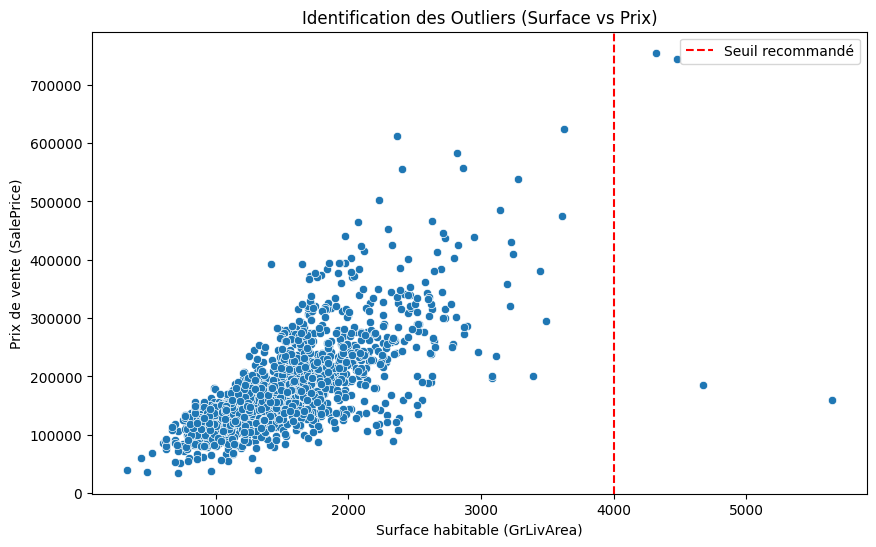

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("Identification des Outliers (Surface vs Prix)")
plt.xlabel("Surface habitable (GrLivArea)")
plt.ylabel("Prix de vente (SalePrice)")
plt.axvline(x=4000, color='r', linestyle='--', label='Seuil recommandé')
plt.legend()
plt.show()

#### 3. Suppression des valeurs aberrantes
On cible les maisons > 4000 sq ft qui ont un prix anormalement bas

In [31]:
outliers_index = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index
print(f"Nombre de points supprimés : {len(outliers_index)}")

df_cleaned = df.drop(outliers_index)

Nombre de points supprimés : 2


#### 4. Visualisation après nettoyage

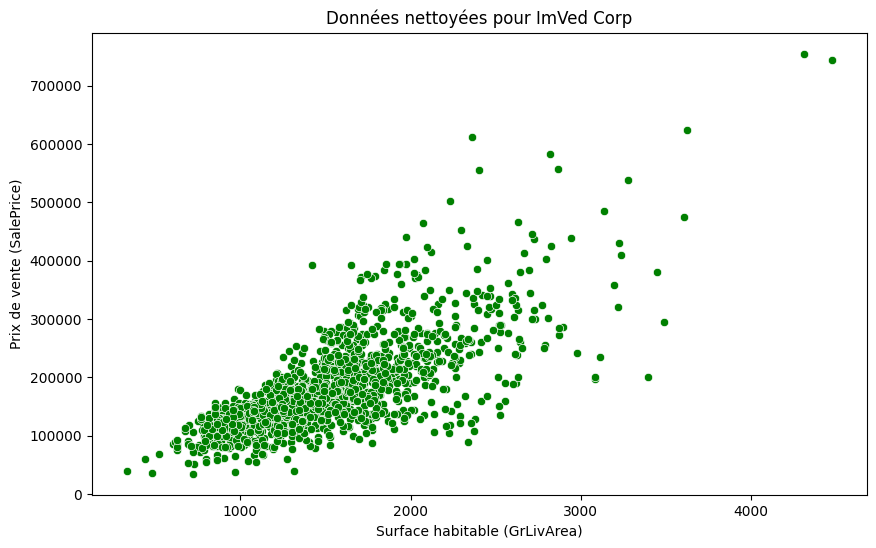

Statistiques après nettoyage :
         GrLivArea      SalePrice
count  1458.000000    1458.000000
mean   1510.465706  180932.919067
std     507.878508   79495.055285
min     334.000000   34900.000000
25%    1128.500000  129925.000000
50%    1461.500000  163000.000000
75%    1776.000000  214000.000000
max    4476.000000  755000.000000


In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_cleaned['GrLivArea'], y=df_cleaned['SalePrice'], color='green')
plt.title("Données nettoyées pour ImVed Corp")
plt.xlabel("Surface habitable (GrLivArea)")
plt.ylabel("Prix de vente (SalePrice)")
plt.show()

# 5. Application de la transformation logarithmique sur la cible
# (Indispensable pour la métrique RMSE sur logs demandée)
df_cleaned['SalePrice_Log'] = np.log1p(df_cleaned['SalePrice'])

print("Statistiques après nettoyage :")
print(df_cleaned[['GrLivArea', 'SalePrice']].describe())

#### Imputer les valeurs manquantes NA

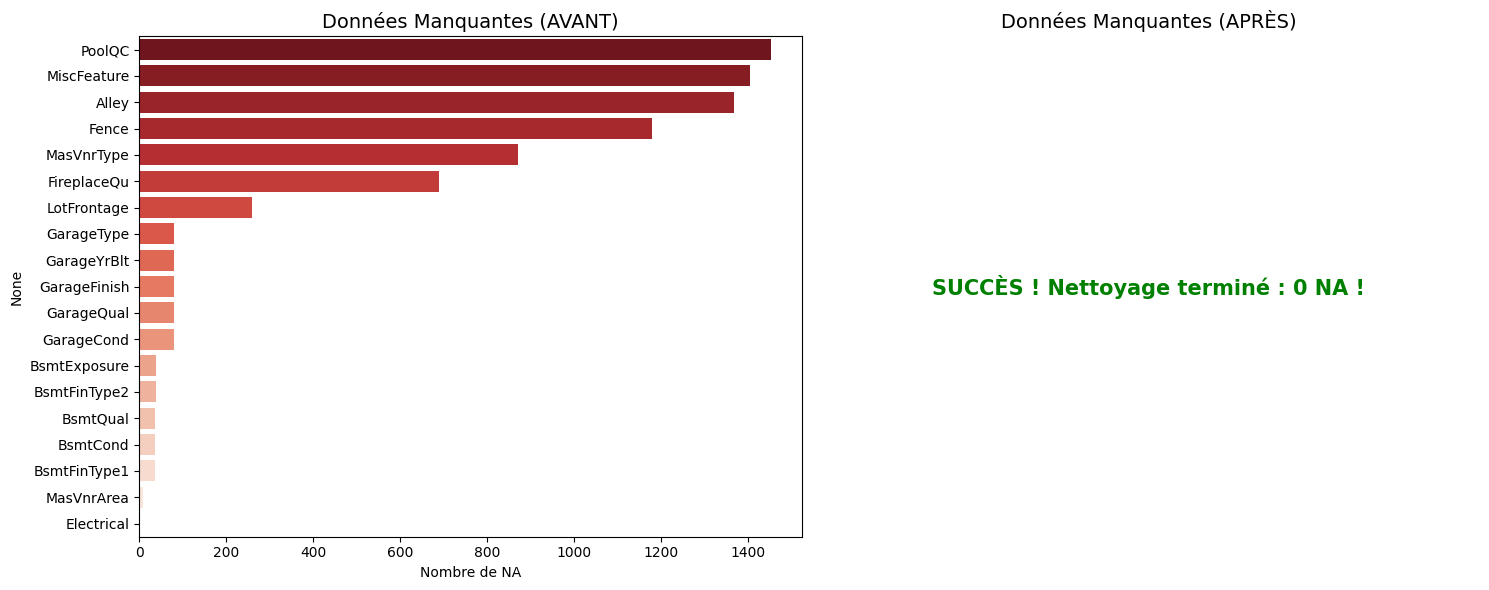

Total NA avant : 7829
Total NA après  : 0


In [34]:
# 1. Chargement des données (Séparateur spécifique ;)
df = pd.read_csv('./Data/train.csv', sep=',')

# 2. Définition de la fonction d'imputation "Intelligente"
def intelligent_imputation(df):
    df_imputed = df.copy()

    # NA = "None" (Absence d'équipement)
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'MasVnrType']
    for col in none_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna('None')

    # NA = 0 (Absence de surface/garage)
    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath',
                 'BsmtHalfBath', 'MasVnrArea']
    for col in zero_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna(0)

    # Imputation par la médiane du quartier (LotFrontage)
    if 'LotFrontage' in df_imputed.columns and 'Neighborhood' in df_imputed.columns:
        df_imputed['LotFrontage'] = df_imputed.groupby('Neighborhood')['LotFrontage'].transform(
            lambda x: x.fillna(x.median())
        )

    # Imputation par le Mode (Valeurs les plus fréquentes)
    mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
    for col in mode_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

    # Cas particulier Functional
    if 'Functional' in df_imputed.columns:
        df_imputed['Functional'] = df_imputed['Functional'].fillna('Typ')

    # Suppression Utilities (Trop peu d'information)
    if 'Utilities' in df_imputed.columns:
        df_imputed = df_imputed.drop(['Utilities'], axis=1)

    return df_imputed

# 3. Analyse AVANT Imputation
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

# 4. Exécution de l'imputation
df_cleaned = intelligent_imputation(df)

# 5. Analyse APRÈS Imputation
missing_after = df_cleaned.isnull().sum()
missing_after = missing_after[missing_after > 0] # On espère que c'est vide !

# 6. Visualisation comparative
plt.figure(figsize=(15, 6))

# Graphique AVANT
plt.subplot(1, 2, 1)
if not missing_before.empty:
    sns.barplot(x=missing_before.values, y=missing_before.index, hue=missing_before.index, palette='Reds_r', legend=False)
    plt.title("Données Manquantes (AVANT)", fontsize=14)
    plt.xlabel("Nombre de NA")
else:
    plt.text(0.5, 0.5, "Aucune donnée manquante", ha='center')

# Graphique APRÈS
plt.subplot(1, 2, 2)
if not missing_after.empty:
    sns.barplot(x=missing_after.values, y=missing_after.index, hue=missing_before.index, palette='Blues_r', legend=False)
    plt.title("Données Manquantes restantes (APRÈS)", fontsize=14)
else:
    # Si tout est propre, on affiche un message de succès
    plt.text(0.5, 0.5, "SUCCÈS ! Nettoyage terminé : 0 NA !",
             ha='center', va='center', fontsize=15, color='green', fontweight='bold')
    plt.title("Données Manquantes (APRÈS)", fontsize=14)
    plt.gca().set_axis_off()

plt.tight_layout()
plt.show()

# Affichage du résumé final
print(f"Total NA avant : {missing_before.sum()}")
print(f"Total NA après  : {df_cleaned.isnull().sum().sum()}")

#### Préparation des données (à affiner)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


# 1. Séparer les caractéristiques (X) de la cible (y)
# On retire 'SalePrice' (la cible) et 'Id' (inutile pour prédire)
X = df_cleaned.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y = df_cleaned['SalePrice']

# 2. Créer la cible en logarithme (indispensable pour votre métrique RMSE sur log)
y_log = np.log1p(y)

# 3. Découper le dataset (80% pour l'entraînement, 20% pour la validation)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Initialiser le modèle RandomForest (qui semblait manquer aussi)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

print(f"Données d'entraînement : {X_train.shape}")
print(f"Données de validation  : {X_test.shape}")

Données d'entraînement : (1168, 78)
Données de validation  : (292, 78)


In [43]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# --- 1. ENCODAGE ORDINAL (Qualité) ---
ord_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].map(ord_map)

# --- 2. ENCODAGE ONE-HOT (Variables textuelles restantes comme 'RL') ---
# C'est ici que 'RL' devient une colonne numérique
df_final = pd.get_dummies(df_cleaned)

# --- 3. GESTION DES VALEURS MANQUANTES ---
# Le Gradient Boosting ne tolère aucun vide (NaN)
df_final = df_final.fillna(0)

# --- 4. CRÉATION DES VARIABLES X et Y ---
X = df_final.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y_log = np.log1p(df_final['SalePrice'])

# --- 5. SPLIT TRAIN/TEST ---
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- 6. INITIALISATION ET ENTRAÎNEMENT ---
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Maintenant ça fonctionne, car X_train ne contient plus que des nombres !
rf.fit(X_train, y_train_log)
gb.fit(X_train, y_train_log)

print("Succès : Les modèles sont entraînés !")

Succès : Les modèles sont entraînés !


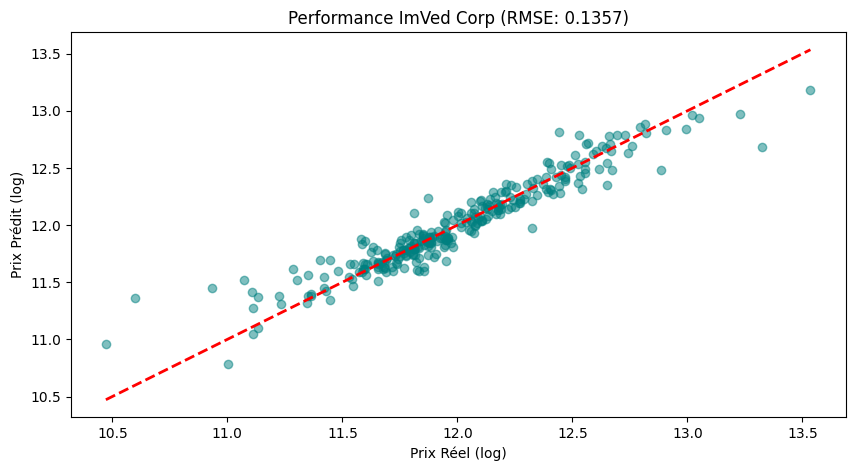

Le score RMSE final du modèle sélectionné est : 0.1357


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- 1. ENCODAGE (Correction de l'erreur 'RL') ---
# Transformation des variables qualitatives en chiffres
df_final = pd.get_dummies(df_cleaned)

# --- 2. PRÉPARATION DES DONNÉES ---
X = df_final.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y_log = np.log1p(df_final['SalePrice'])

# Séparation Train (80%) / Test (20%)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- 3. ENTRAÎNEMENT ---
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

rf.fit(X_train, y_train_log)
gb.fit(X_train, y_train_log)

# --- 4. ÉVALUATION ET GRAPHIQUES ---
y_pred_gb = gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test_log, y_pred_gb))

plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_pred_gb, alpha=0.5, color='teal')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
plt.title(f"Performance ImVed Corp (RMSE: {rmse_gb:.4f})")
plt.xlabel("Prix Réel (log)")
plt.ylabel("Prix Prédit (log)")
plt.show()

print(f"Le score RMSE final du modèle sélectionné est : {rmse_gb:.4f}")

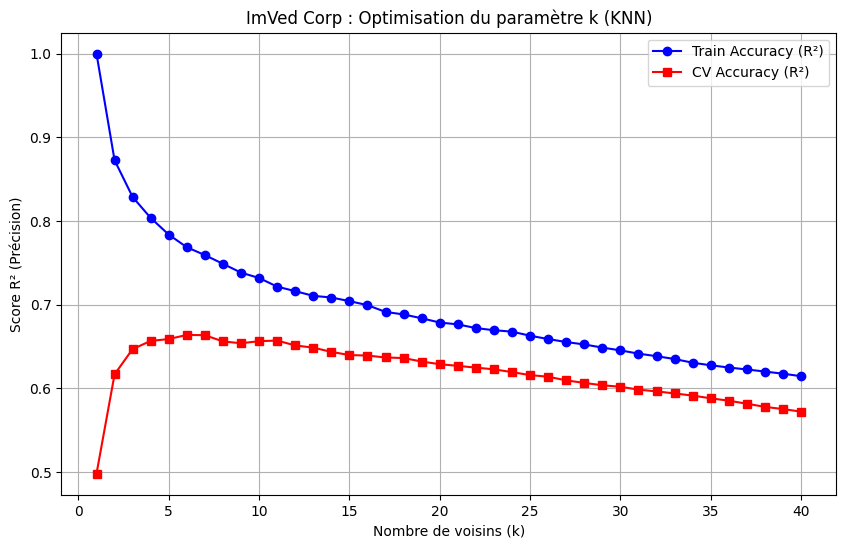

Le meilleur k pour la validation croisée est : 6


In [45]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# 1. Définir une plage de k (ex: de 1 à 40)
k_range = range(1, 41)
train_scores = []
cv_scores = []

# 2. Boucle pour tester chaque valeur de k
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)

    # Score d'entraînement (sur y_train_log)
    knn.fit(X_train, y_train_log)
    train_scores.append(knn.score(X_train, y_train_log))

    # Score de Validation Croisée (CV) - Moyenne de 5-folds
    scores = cross_val_score(knn, X_train, y_train_log, cv=5)
    cv_scores.append(scores.mean())

# 3. Visualisation des "Accuracies" (R² Score)
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Train Accuracy (R²)', color='blue', marker='o')
plt.plot(k_range, cv_scores, label='CV Accuracy (R²)', color='red', marker='s')

plt.title('ImVed Corp : Optimisation du paramètre k (KNN)')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Score R² (Précision)')
plt.legend()
plt.grid(True)
plt.show()

# Identifier le meilleur k
best_k = k_range[np.argmax(cv_scores)]
print(f"Le meilleur k pour la validation croisée est : {best_k}")

Début de l'évaluation des modèles pour InVed Corp...
SUCCÈS ! Random Forest terminé. RMSE : 0.1465
SUCCÈS ! AdaBoost terminé. RMSE : 0.1821
SUCCÈS ! XGBoost terminé. RMSE : 0.1414
SUCCÈS ! Stacking terminé. RMSE : 0.1347


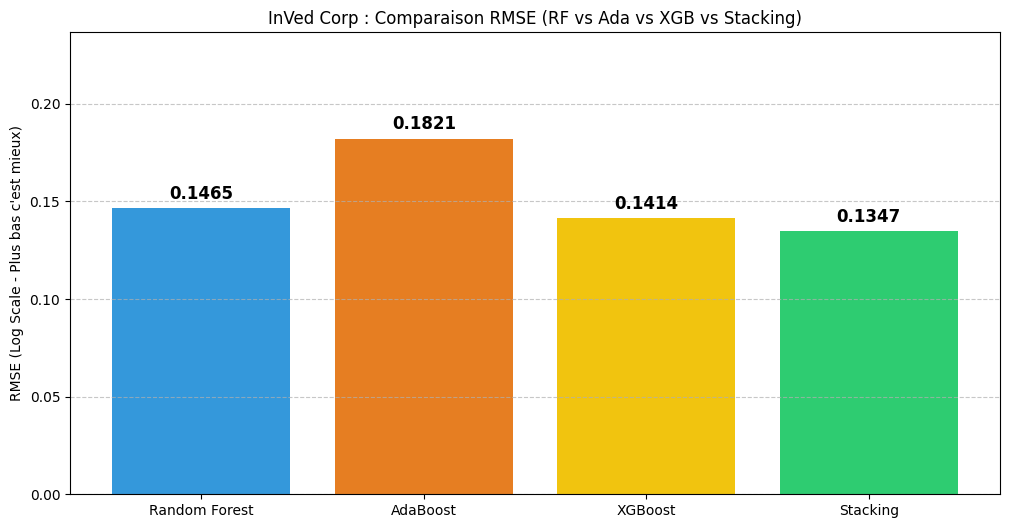

In [47]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor # Ajout de XGBoost
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Définition des modèles ---

# Modèle 1 : Random Forest (Baseline)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Modèle 2 : AdaBoost
ada = AdaBoostRegressor(n_estimators=100, random_state=42)

# Modèle 3 : XGBoost (Le nouveau challenger performant)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)

# Modèle 4 : Stacking (L'ensemble combiné)
# On peut aussi ajouter XGBoost à l'intérieur du stacking pour encore plus de puissance
estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42))
]
stack = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())

# --- 2. Entraînement et Évaluation ---

# Ajout de XGBoost au dictionnaire
models = {
    'Random Forest': rf,
    'AdaBoost': ada,
    'XGBoost': xgb,
    'Stacking': stack
}
results_rmse = {}

print("Début de l'évaluation des modèles pour InVed Corp...")
for name, model in models.items():
    model.fit(X_train, y_train_log)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_log, preds))
    results_rmse[name] = rmse
    print(f"SUCCÈS ! {name} terminé. RMSE : {rmse:.4f}")

# --- 3. Visualisation de la performance ---

plt.figure(figsize=(12, 6))
# Mise à jour des couleurs pour inclure le 4ème modèle
colors = ['#3498db', '#e67e22', '#f1c40f', '#2ecc71']
bars = plt.bar(results_rmse.keys(), results_rmse.values(), color=colors)
plt.title('InVed Corp : Comparaison RMSE (RF vs Ada vs XGB vs Stacking)')
plt.ylabel('RMSE (Log Scale - Plus bas c\'est mieux)')
plt.ylim(0, max(results_rmse.values()) * 1.3)

# Ajout des étiquettes de score sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4),
             ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Évaluation des modèles de régularisation linéaire ---
SUCCÈS ! Lasso terminé. RMSE : 0.1265
SUCCÈS ! Ridge terminé. RMSE : 0.1210
SUCCÈS ! ElasticNet terminé. RMSE : 0.1268


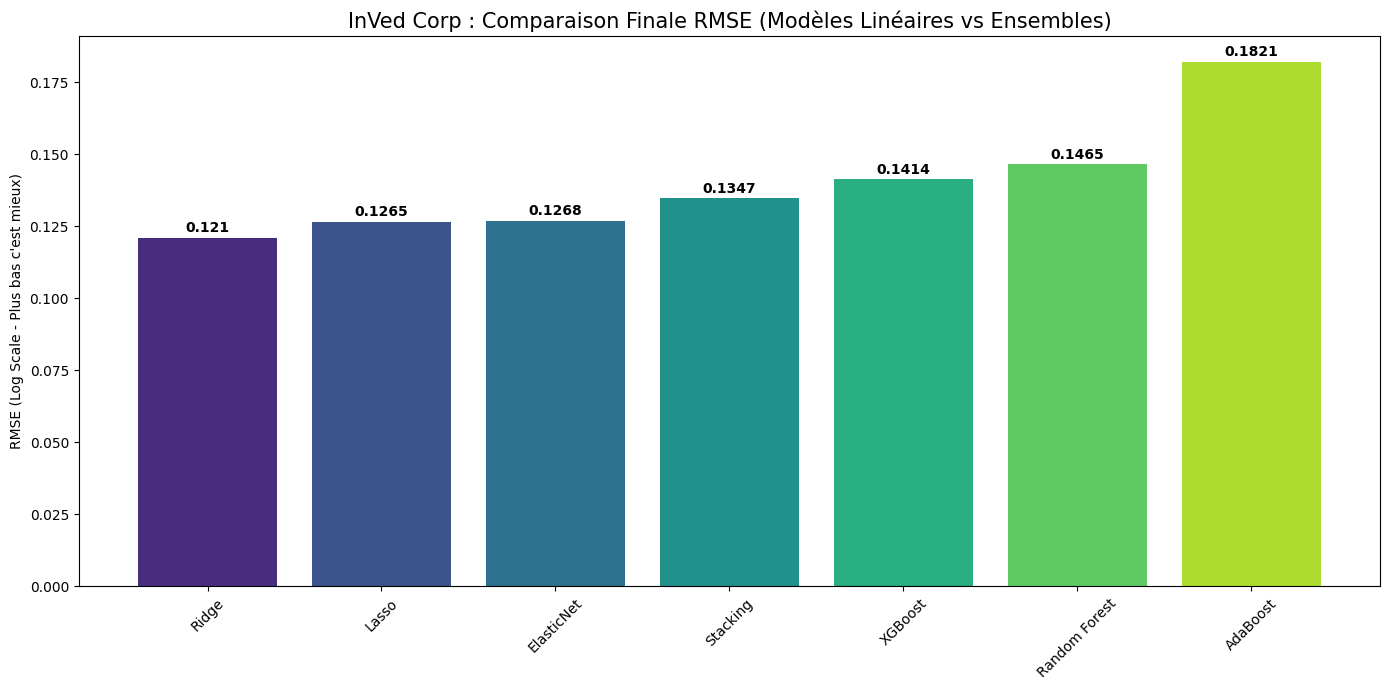


--- Analyse de Robustesse (Lasso) ---
Variables totales : 260
Variables ignorées (Coef = 0) : 204
Variables conservées : 56

Top 10 des variables les plus déterminantes pour le prix :
              Feature  Importance
20          GrLivArea    0.125910
3         OverallQual    0.086597
133  RoofMatl_ClyTile    0.062579
5           YearBuilt    0.041377
4         OverallCond    0.029573
15        TotalBsmtSF    0.026867
110   Condition2_PosN    0.025530
12         BsmtFinSF1    0.023584
33         GarageArea    0.022564
32         GarageCars    0.022549


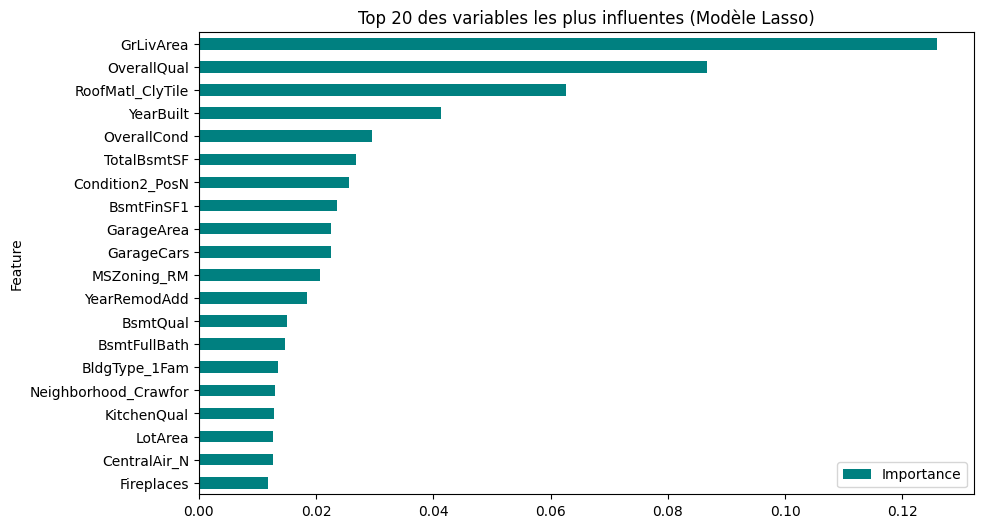

In [51]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Définition des modèles avec Pipeline (Scaling + Modèle) ---
# Le scaling est CRUCIAL pour Lasso/Ridge. max_iter est augmenté pour éviter les warnings de convergence.

lasso_pipe = make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50000, random_state=42))
ridge_pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 2, 20), cv=5))
elastic_pipe = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                                                           alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50000, random_state=42))

# --- 2. Mise à jour du dictionnaire de modèles ---
# On ajoute ces nouveaux modèles à ceux que tu as déjà (RF, XGB, etc.)
new_models = {
    'Lasso': lasso_pipe,
    'Ridge': ridge_pipe,
    'ElasticNet': elastic_pipe
}

# Si tu veux fusionner avec tes anciens modèles pour le graphique final :
# models.update(new_models)

print("\n--- Évaluation des modèles de régularisation linéaire ---")

for name, model in new_models.items():
    model.fit(X_train, y_train_log)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_log, preds))
    results_rmse[name] = rmse  # On stocke dans ton dictionnaire de résultats global
    print(f"SUCCÈS ! {name} terminé. RMSE : {rmse:.4f}")

# --- 3. Visualisation comparative mise à jour ---
plt.figure(figsize=(14, 7))
# On trie les résultats du meilleur (plus bas RMSE) au moins bon
sorted_results = dict(sorted(results_rmse.items(), key=lambda item: item[1]))

colors = sns.color_palette("viridis", len(sorted_results))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), color=colors)

plt.title('InVed Corp : Comparaison Finale RMSE (Modèles Linéaires vs Ensembles)', fontsize=15)
plt.ylabel('RMSE (Log Scale - Plus bas c\'est mieux)')
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4),
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- 4. BONUS : Analyse des variables sélectionnées par le Lasso ---

# Pour accéder aux coefficients, on doit "entrer" dans le pipeline via 'lassocv'
lasso_final = lasso_pipe.named_steps['lassocv']
n_zero = np.sum(lasso_final.coef_ == 0)
n_total = len(lasso_final.coef_)

print(f"\n--- Analyse de Robustesse (Lasso) ---")
print(f"Variables totales : {n_total}")
print(f"Variables ignorées (Coef = 0) : {n_zero}")
print(f"Variables conservées : {n_total - n_zero}")

# Top 10 des variables les plus importantes
coef_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lasso_final.coef_)
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 des variables les plus déterminantes pour le prix :")
print(coef_importance.head(10))

# Visualisation des coefficients
plt.figure(figsize=(10, 6))
coef_importance.head(20).plot(kind='barh', x='Feature', y='Importance', color='teal', ax=plt.gca())
plt.title("Top 20 des variables les plus influentes (Modèle Lasso)")
plt.gca().invert_yaxis()
plt.show()